<a href="https://colab.research.google.com/github/Ericharw/Machine_Learning/blob/main/JS04_2341720202_Ericha%20Rizki%20W.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama : Ericha Rizki Wardani**

**Kelas : TI 3C**

**NIM : 2341720202**

# **Praktikum 1**

**KMeans**

KMeans adalah satu metode unsupervised learning pada machine learning. Metode ini menentukan jumlah cluster sesuai dengan jumlah
k
k yang dipilih. Proses KMeans secara manual, dapat dilihat pada tautan berikut,

Pada modul jobsheet ini, kita akan langsung mempraktikkan pembuatan model KMeans dengan menggunakan python. Untuk modul pertama ini, kita akan menggunakan contoh kasus yang sederhana, yaitu dengan menggunakan dataset iris. Sedangkan untuk modul kedua, kita akan melakukan clustering dengan lebih advance, yaitu reduksi warna dengan data gambar.

In [ ]:
import pandas as pd


from google.colab import files
uploaded = files.upload() # upload dataset

data = 'Iris.csv' # path dataset
df = pd.read_csv(data) # load dataset

Saving Iris.csv to Iris.csv


In [ ]:
#Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


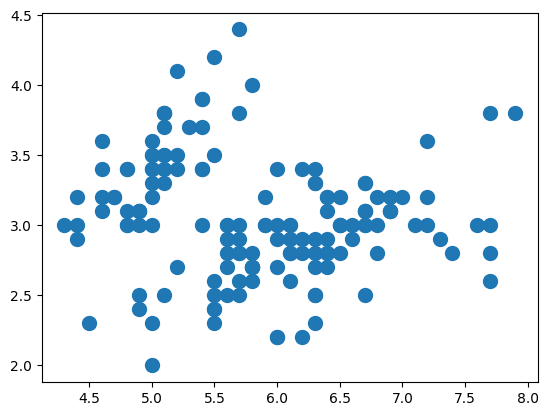

In [ ]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

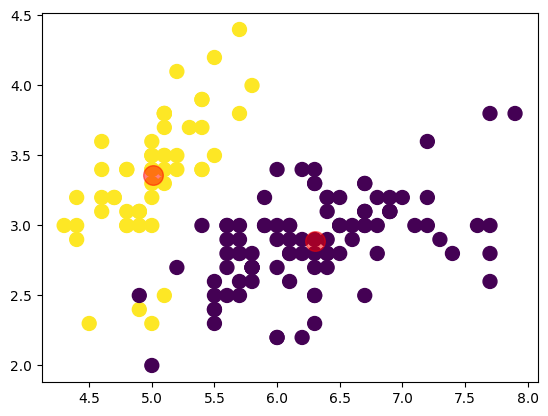

In [ ]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [ ]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


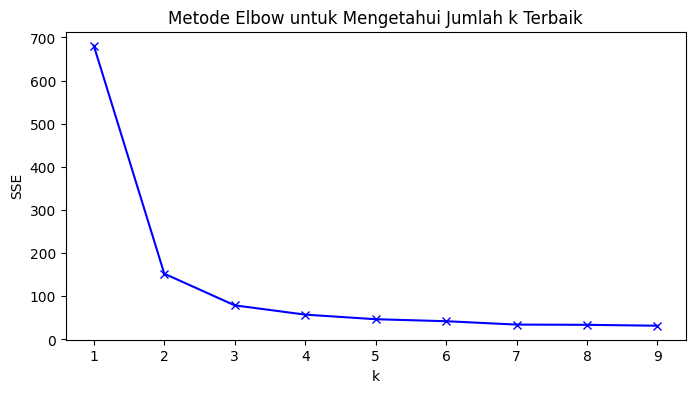

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [ ]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.4732732654949
k=5; SSE=46.80170193050192
k=6; SSE=42.20420824175824
k=7; SSE=34.38257515043647
k=8; SSE=33.82443004737781
k=9; SSE=31.74330610952514


# **Praktikum 2**

In [ ]:
#Import library
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

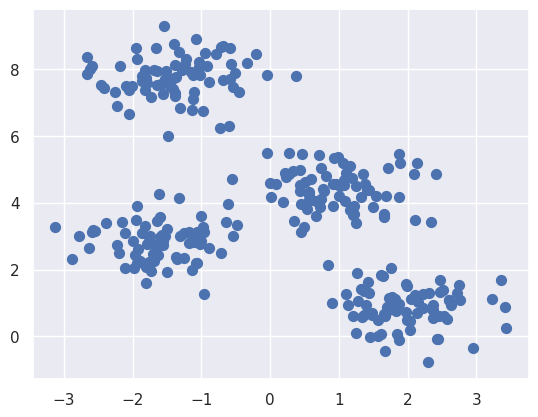

In [ ]:
# Pengantar KMeans
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

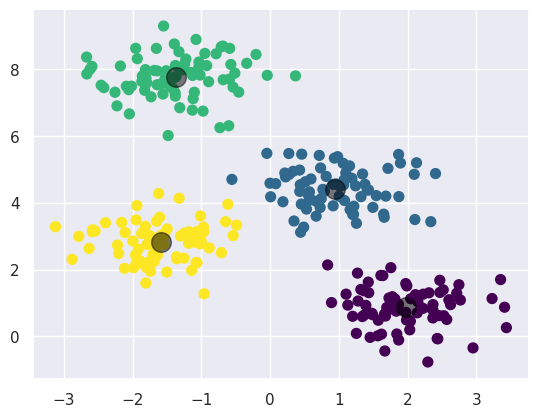

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

**Algoritma Expectation-Maximization**

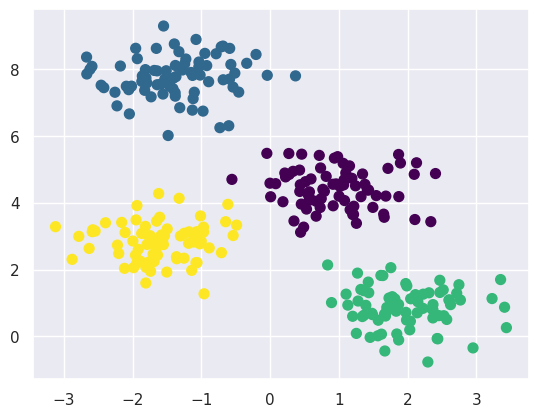

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

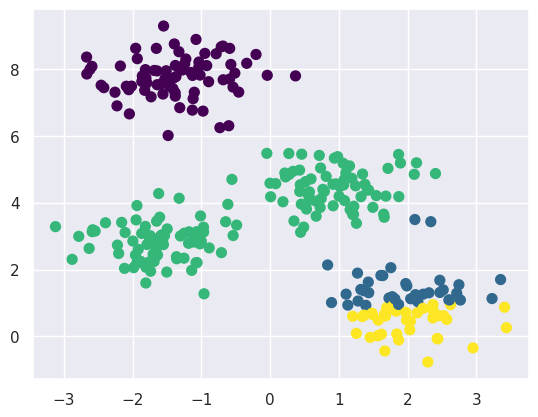

In [ ]:
# Perubahan Random
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

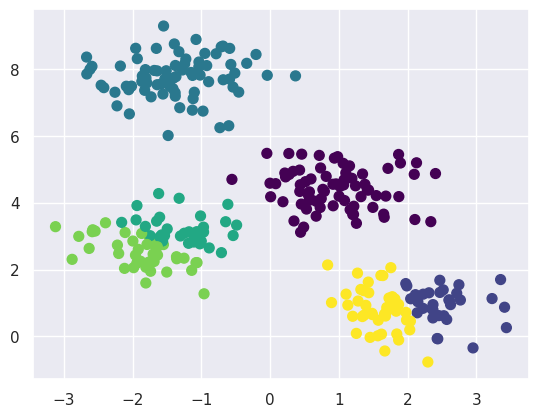

In [ ]:
#Optimalisasi Jumlah Klaster
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

**Batas Klaster yang Tidak Selalu Linier**

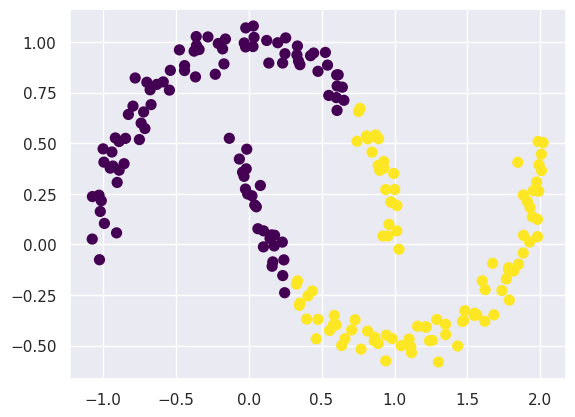

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


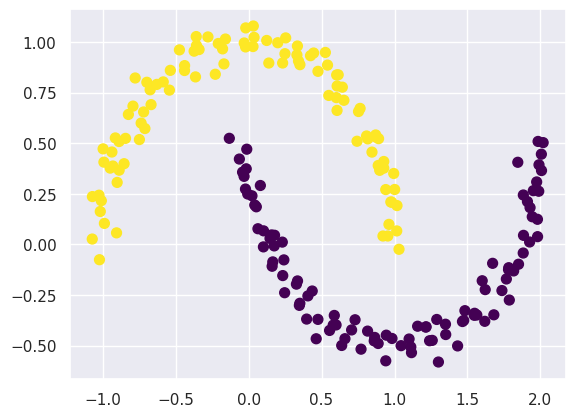

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

# **Contoh Kasus 1: Karakter Angka**

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

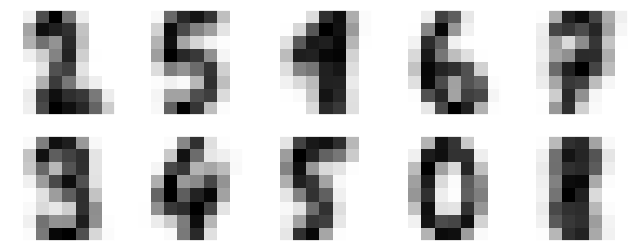

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [ ]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

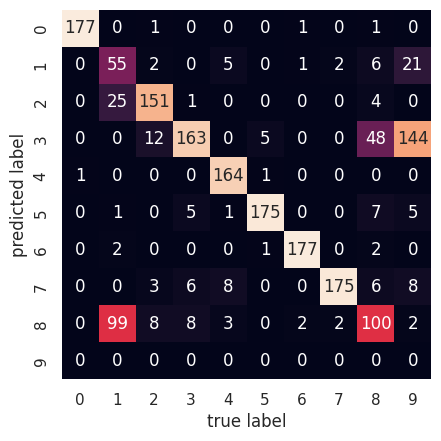

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

# **Studi Kasus 2 : Kompresi Citra**

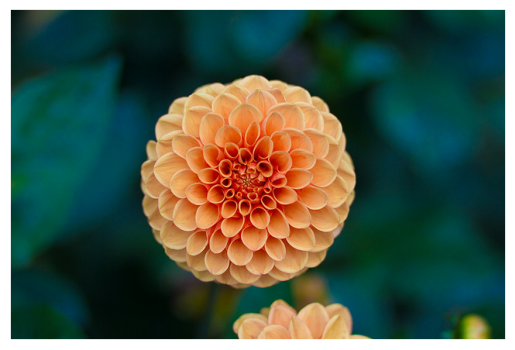

In [ ]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [ ]:
flower.shape

(427, 640, 3)

In [ ]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

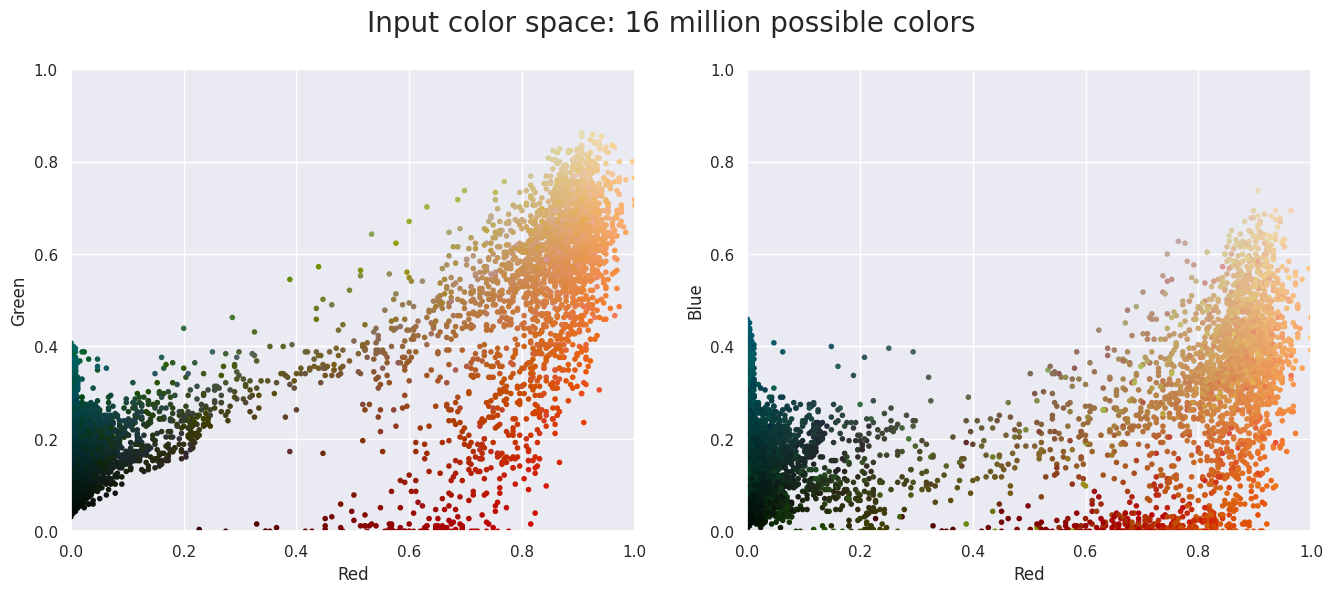

In [ ]:
plot_pixels(data, title='Input color space: 16 million possible colors')

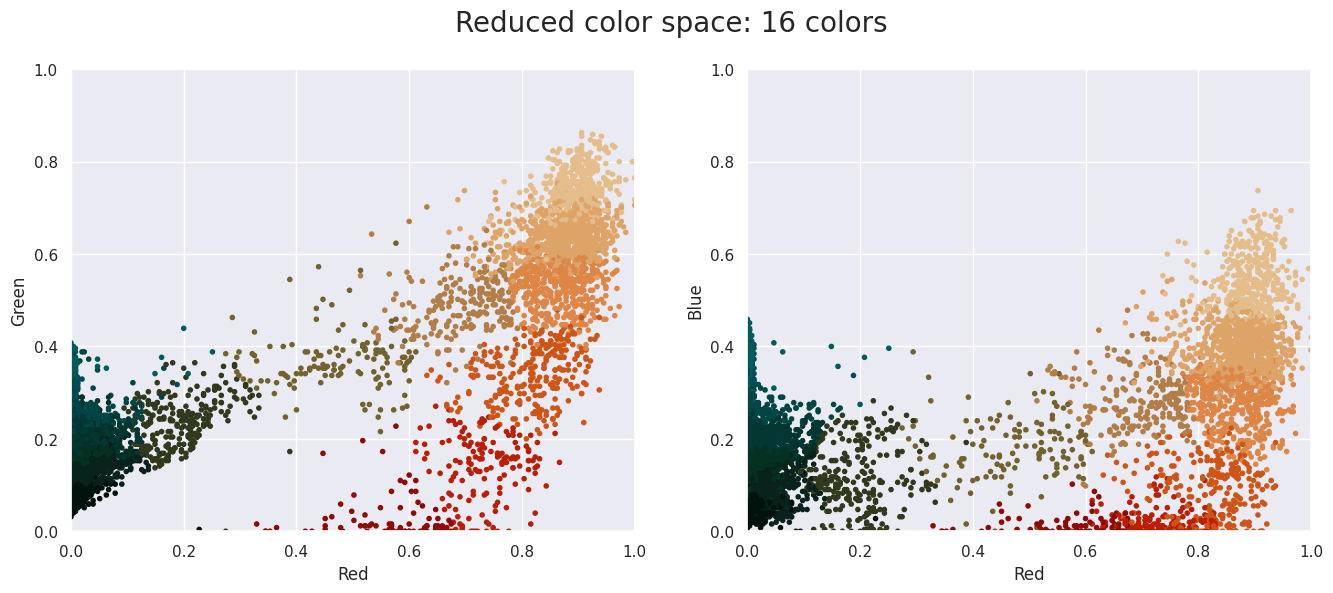

In [ ]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

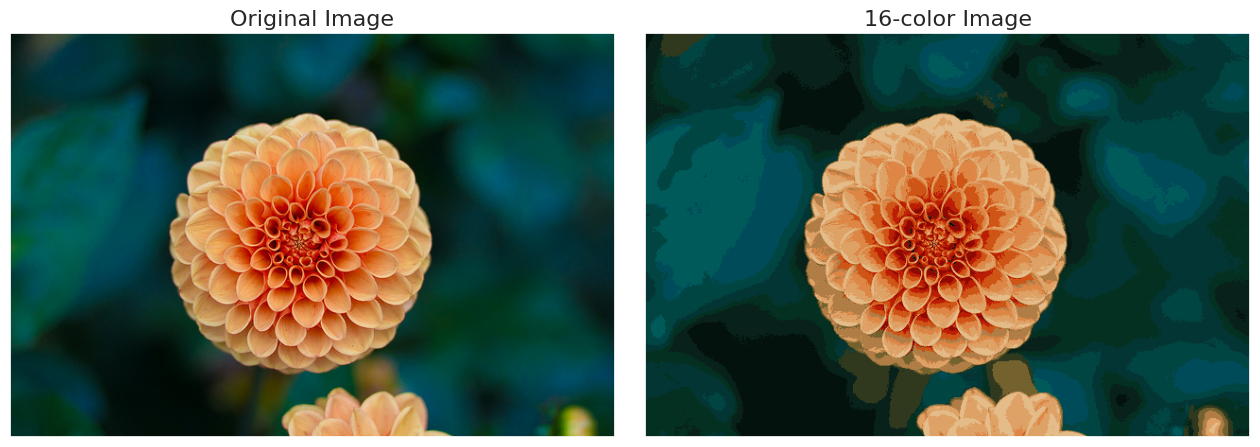

In [ ]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# **Praktikum 3**

**Pembuatan Dataset Sintetis**

Untuk mempelajari DBSCAN, kita akan membuat dataset sederhana berupa 3 klaster buatan menggunakan fungsi  make_blobs  dari Scikit-Learn.

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Mendefinisikan pusat cluster
centers = [[1, 1], [-1, -1], [1, -1]]

# Membuat dataset menggunakan make_blobs
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

# Membuat objek StandardScaler dan melakukan scaling pada data X
X = StandardScaler().fit_transform(X)

# (Opsional) Menampilkan 5 baris pertama dari data yang sudah di-scaling
print(X[:5])

[[ 0.49426097  1.45106697]
 [-1.42808099 -0.83706377]
 [ 0.33855918  1.03875871]
 [ 0.11900101 -1.05397553]
 [ 1.1224246   1.77493654]]


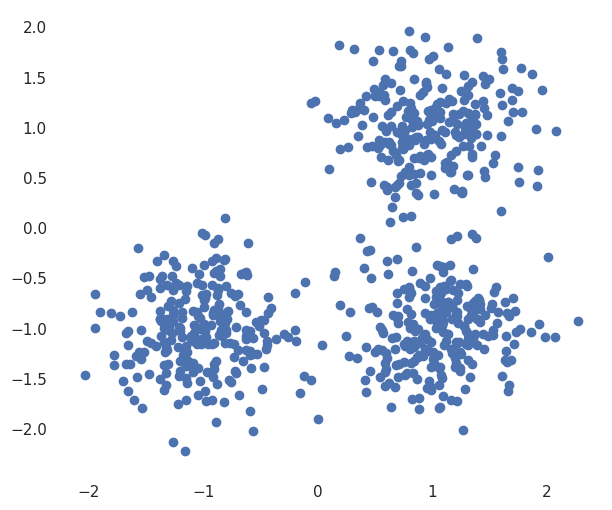

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

# Diasumsikan variabel 'X' sudah ada dari kode sebelumnya.
# Jika belum, jalankan blok kode ini terlebih dahulu untuk membuat data.
if 'X' not in locals():
    centers = [[1, 1], [-1, -1], [1, -1]]
    X, _ = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=0)


# --- Mulai Kode Inti ---

# 1. Inisialisasi "kanvas" (figure) dan "area gambar" (axes)
fig, ax = plt.subplots(figsize=(7, 6))

# 2. Gambar data dan atur tampilan plot
ax.scatter(X[:, 0], X[:, 1])
ax.set_facecolor('white')
ax.set_yticks(np.arange(-2.0, 2.5, 0.5))

# 3. Tampilkan hasil akhir
plt.show()

**Compute DBSCAN**

Sekarang kita terapkan DBSCAN pada data tersebut.

Label yang ditetapkan oleh DBSCAN dapat diakses melalui atribut labels_. Titik data yang dianggap noise akan diberi label khusus.

In [ ]:
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN # 1. Impor DBSCAN

# Diasumsikan variabel 'X' sudah ada dari kode sebelumnya
if 'X' not in locals():
    from sklearn.datasets import make_blobs
    centers = [[1, 1], [-1, -1], [1, -1]]
    X, _ = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=0)

# 2. Buat objek DBSCAN lalu jalankan .fit()
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Menghitung jumlah cluster (mengabaikan noise/outlier)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1) # Titik noise diberi label -1

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 22


**Evaluasi Kualitas Klasterisasi**

Karena kita menggunakan dataset sintetis (make_blobs), kita tahu label aslinya (labels_true). Ini memungkinkan kita mengukur kualitas DBSCAN dengan berbagai metrik evaluasi.

In [ ]:
from sklearn import metrics
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.947
Completeness: 0.868
V-measure: 0.906
Adjusted Rand Index: 0.943
Adjusted Mutual Information: 0.905
Silhouette Coefficient: 0.621


**Visualisasi Hasil Klasterisasi**

Kita akan memvisualisasikan hasil DBSCAN.

- Core sample ditampilkan dengan titik besar.

- Non-core sample ditampilkan dengan titik kecil.

- Noise ditampilkan dengan warna hitam.

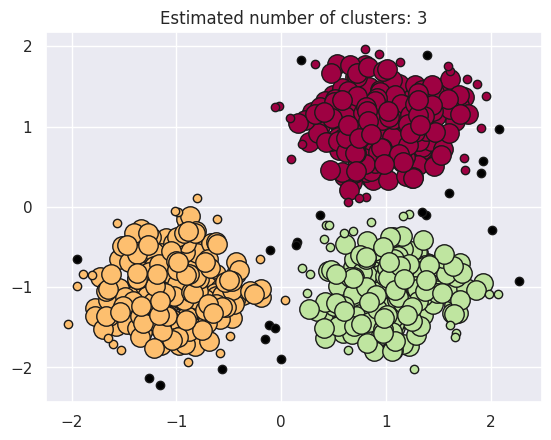

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

# Looping untuk menggambar setiap cluster
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Gambar titik-titik yang BUKAN core samples (ukuran kecil)
    xy = X[class_member_mask & ~core_samples_mask]
    # 3. Perbaikan: Memanggil fungsi plt.plot() lagi
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# **Tugas Praktikum**

## **1. Tugas K-Means**

Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import files
uploaded = files.upload() # upload dataset

data = 'Mall_Customers.csv' # path dataset
df = pd.read_csv(data) # load dataset
df.head()

Saving Mall_Customers.csv to Mall_Customers (1).csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Pilih fitur untuk clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

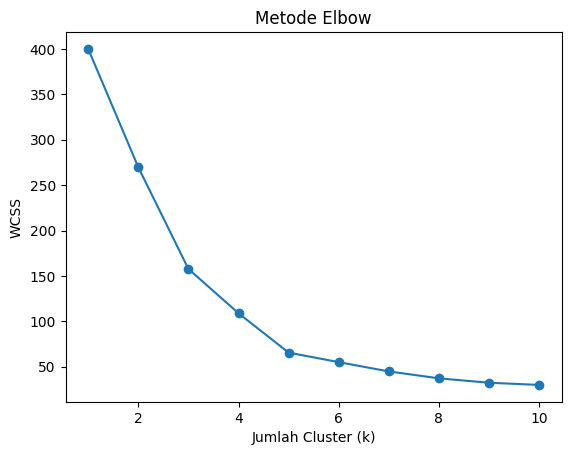

In [6]:
# Normalisasi Data (Optional Tapi Disarankan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Menentukan jumlah cluster terbaik (Elbow Method)
wcss = []  # Within Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.title('Metode Elbow')
plt.show()


In [8]:
# Model K-Means dengan k terbaik
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Menambahkan hasil cluster ke dataframe
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


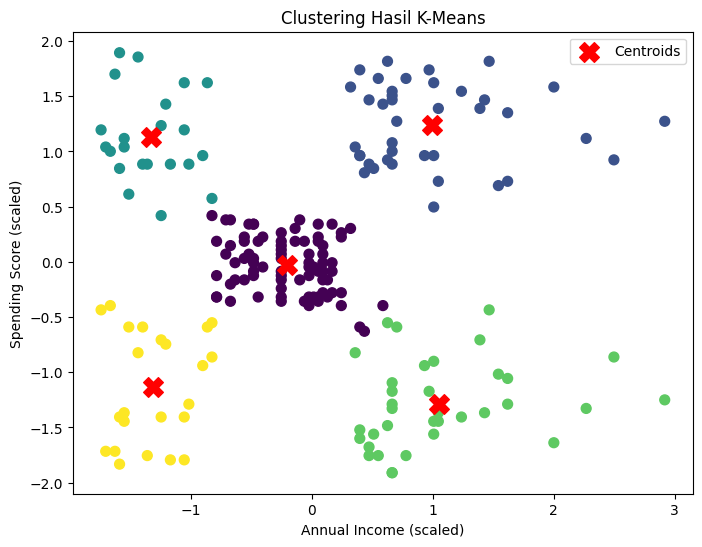

In [9]:
# VIsualisasi Hasil Clustering
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Clustering Hasil K-Means')
plt.legend()
plt.show()

## **Tugas DBSCAN**

1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
*   eps = 0.05, 0.1, 0.3, 0.5
*   min_samples = 3, 10, 20
* Catat perubahan klaster, noise, dan kualitas evaluasi.



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score

In [11]:
# Dataset make_moons
X, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Normalisasi
X = StandardScaler().fit_transform(X)

In [12]:
def evaluate_dbscan(X, labels):
    # Jumlah cluster (exclude -1 = noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Evaluasi metrik
    if n_clusters > 1:
        silhouette = silhouette_score(X, labels)
    else:
        silhouette = -1  # Tidak valid jika hanya 1 cluster

    metrics = {
        "Clusters": n_clusters,
        "Noise": n_noise,
        "Homogeneity": homogeneity_score(y_true, labels),
        "Completeness": completeness_score(y_true, labels),
        "V-measure": v_measure_score(y_true, labels),
        "ARI": adjusted_rand_score(y_true, labels),
        "AMI": adjusted_mutual_info_score(y_true, labels),
        "Silhouette": silhouette
    }
    return metrics

In [13]:
def plot_dbscan(X, db, eps, min_samples):
    labels = db.labels_
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True

    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(6,6))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = "k"  # Noise hitam
        class_member_mask = (labels == k)

        xy_core = X[class_member_mask & core_samples_mask]
        xy_border = X[class_member_mask & ~core_samples_mask]

        plt.scatter(xy_core[:,0], xy_core[:,1], s=50, c=[col], marker='o', label=f"Cluster {k}" if k!=-1 else "Noise")
        plt.scatter(xy_border[:,0], xy_border[:,1], s=20, c=[col], marker='.')

    plt.title(f"DBSCAN eps={eps}, min_samples={min_samples}")
    plt.legend()
    plt.show()

Default (eps=0.2, min_samples=5):
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


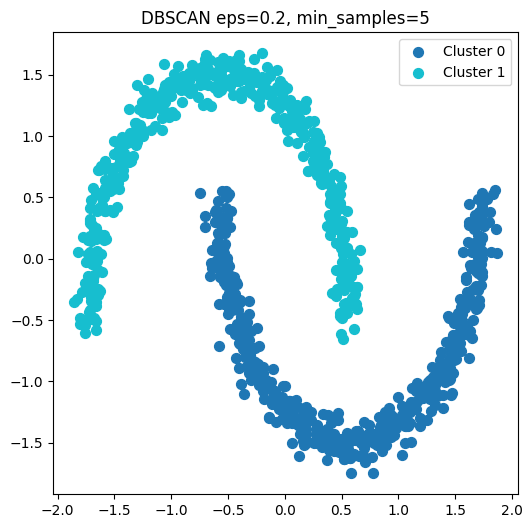

In [14]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

metrics = evaluate_dbscan(X, labels)
print("Default (eps=0.2, min_samples=5):")
for k,v in metrics.items():
    print(f"{k}: {v}")

plot_dbscan(X, db, eps=0.2, min_samples=5)


=== eps=0.05, min_samples=3 ===
Clusters: 69
Noise: 186
Homogeneity: 0.8155542882355717
Completeness: 0.15254831024758073
V-measure: 0.25702116445185835
ARI: 0.03004350976613907
AMI: 0.243804587789628
Silhouette: 0.11292949852882253


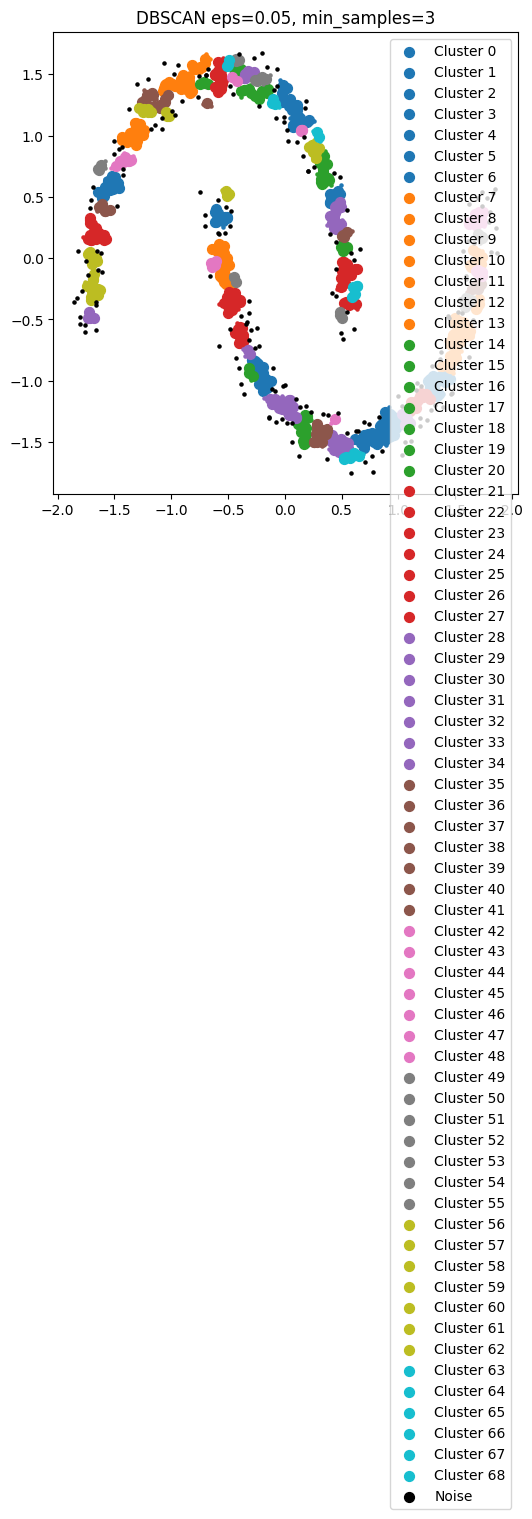


=== eps=0.05, min_samples=10 ===
Clusters: 3
Noise: 970
Homogeneity: 0.030669398254336424
Completeness: 0.126764095870306
V-measure: 0.04938947156339281
ARI: 0.0022825509789741014
AMI: 0.0458636142209481
Silhouette: -0.29419008256642176


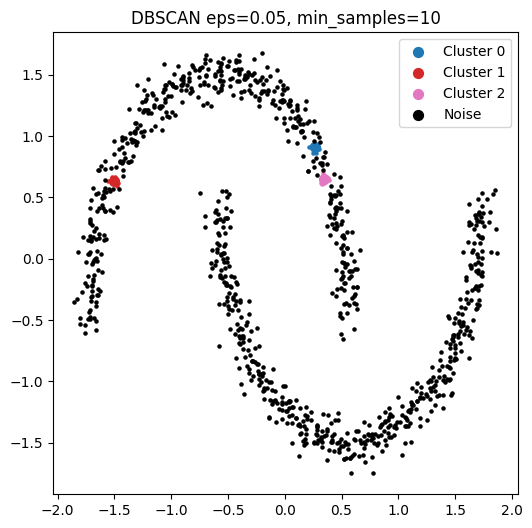


=== eps=0.05, min_samples=20 ===
Clusters: 0
Noise: 1000
Homogeneity: 0.0
Completeness: 1.0
V-measure: 0.0
ARI: 0.0
AMI: 0.0
Silhouette: -1


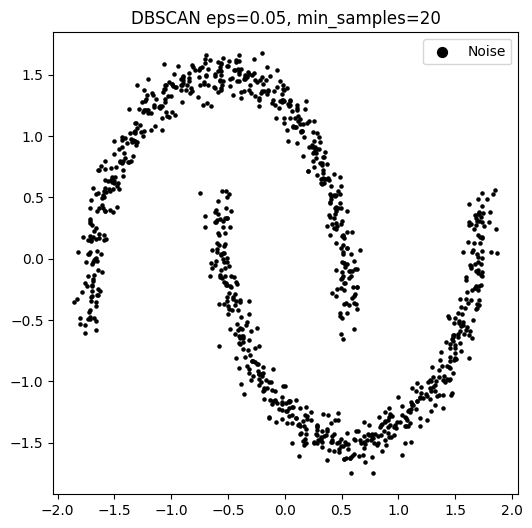


=== eps=0.1, min_samples=3 ===
Clusters: 2
Noise: 14
Homogeneity: 0.9862068060955204
Completeness: 0.9028959083596275
V-measure: 0.9427143195619004
ARI: 0.9721793882692121
AMI: 0.942633562340455
Silhouette: 0.2516903011504368


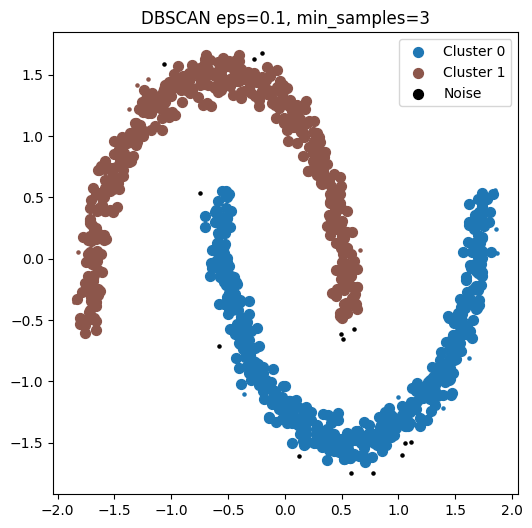


=== eps=0.1, min_samples=10 ===
Clusters: 7
Noise: 57
Homogeneity: 0.9433167874862703
Completeness: 0.4095463775841256
V-measure: 0.571132370522031
ARI: 0.5233989566001742
AMI: 0.5698012090719349
Silhouette: 0.16230611373347142


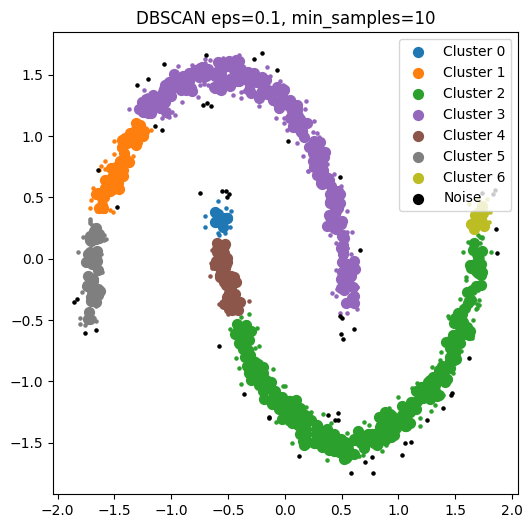


=== eps=0.1, min_samples=20 ===
Clusters: 6
Noise: 850
Homogeneity: 0.1539283270028087
Completeness: 0.15546586661916142
V-measure: 0.15469327639657426
ARI: 0.016753669189074054
AMI: 0.1509160954115189
Silhouette: -0.3601946191938665


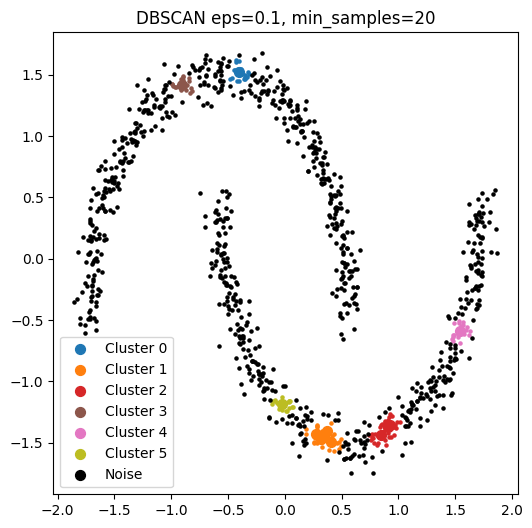


=== eps=0.3, min_samples=3 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


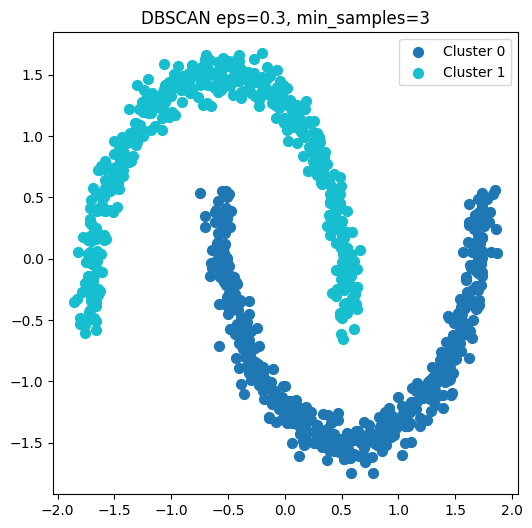


=== eps=0.3, min_samples=10 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


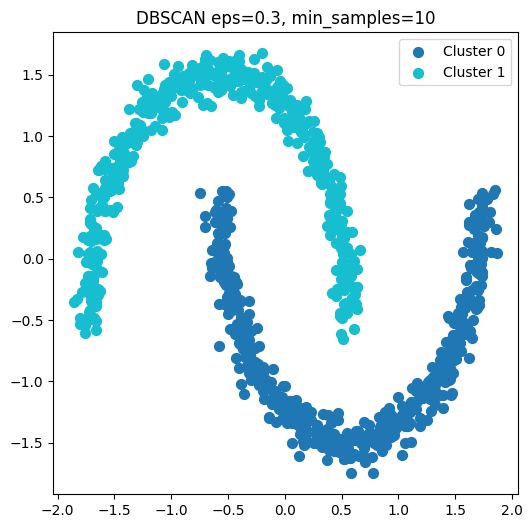


=== eps=0.3, min_samples=20 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


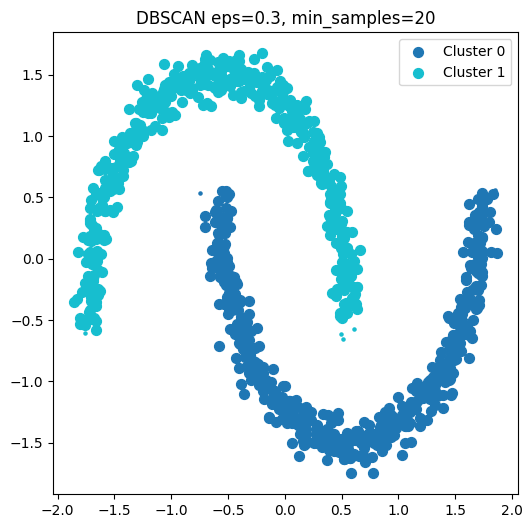


=== eps=0.5, min_samples=3 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


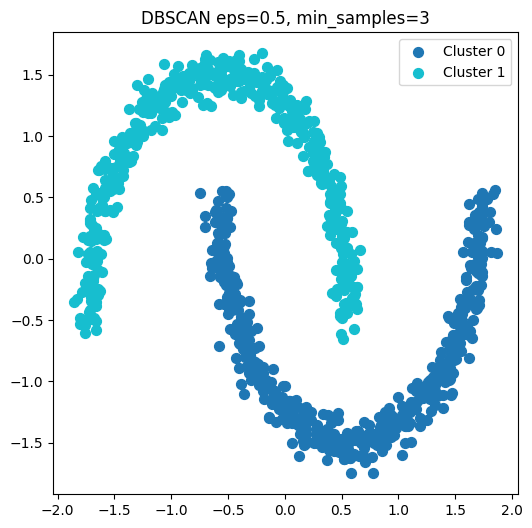


=== eps=0.5, min_samples=10 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


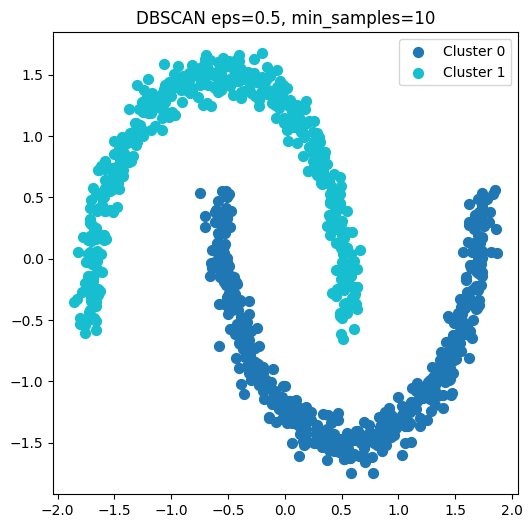


=== eps=0.5, min_samples=20 ===
Clusters: 2
Noise: 0
Homogeneity: 1.0
Completeness: 1.0
V-measure: 1.0
ARI: 1.0
AMI: 1.0
Silhouette: 0.3911598537138403


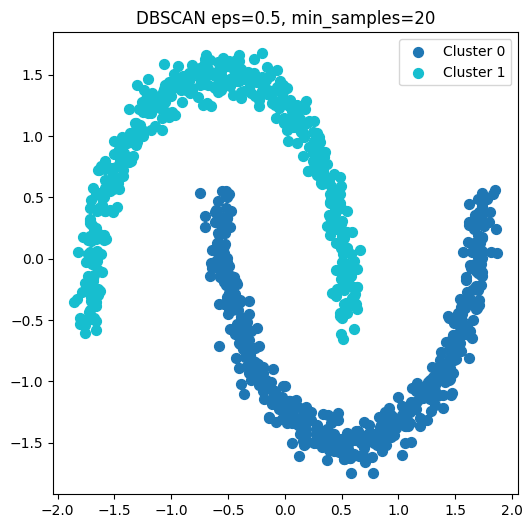

In [15]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X)
        labels = db.labels_
        metrics = evaluate_dbscan(X, labels)
        metrics["eps"] = eps
        metrics["min_samples"] = min_s
        results.append(metrics)
        print(f"\n=== eps={eps}, min_samples={min_s} ===")
        for k,v in metrics.items():
            if k not in ["eps","min_samples"]:
                print(f"{k}: {v}")
        plot_dbscan(X, db, eps, min_s)